In [2]:
import yfinance as yf

spy = yf.download(
    "SPY",
    start="2006-01-01",
    end="2023-06-01"
)

spy

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,SPY,SPY,SPY,SPY,SPY
Date,,,,,
2006-01-03,87.000946,87.206949,85.414743,85.964080,73256700
2006-01-04,87.412964,87.543427,87.000958,87.110828,51899600
2006-01-05,87.467850,87.612050,87.124515,87.309919,47307500
2006-01-06,88.195732,88.291865,87.454129,87.907333,62885900
2006-01-09,88.422325,88.621454,88.154525,88.181987,43527400
...,...,...,...,...,...
2023-05-24,394.577820,396.238342,393.416430,395.854414,89213700
2023-05-25,397.994843,399.444200,395.844825,398.081224,90961600


In [4]:
%pip install matplotlib

   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------- ----------------------- 3.9/9.5 MB 21.3 MB/s eta 0:00:01
   ----------------------------------- ---- 8.4/9.5 MB 22.0 MB/s eta 0:00:01
   ---------------------------------------- 9.5/9.5 MB 21.1 MB/s  0:00:00
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 19.9 MB/s  0:00:00
   ---------------------------------------- 0.0/7.2 MB ? eta -:--:--
   ------------------------ --------------- 4.5/7.2 MB 23.6 MB/s eta 0:00:01
   ---------------------------------------- 7.2/7.2 MB 21.9 MB/s  0:00:00

   ---------------------------------------- 0/7 [pyparsing]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pi

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [1]:
import matplotlib.pyplot as plt

midterm_years = [2006, 2010, 2014, 2018, 2022]

for year in midterm_years:

    # Get SPY prices for this election year
    yearly_spy = data["Close"]["SPY"].loc[
        f"{year}-01-01":f"{year}-12-31"
    ]

    # Convert daily data to weekly data
    weekly_spy = yearly_spy.resample("W-FRI").last()

    # Draw the chart
    weekly_spy.plot(
        figsize=(12, 5),
        marker="o",
        title=f"SPY — {year} Midterm Election Year"
    )

    plt.ylabel("SPY Adjusted Price ($)")
    plt.xlabel("Date")
    plt.grid(True)
    plt.show()

NameError: name 'data' is not defined

In [2]:
import yfinance as yf

data = yf.download(
    "SPY",
    start="2006-01-01",
    end="2023-01-01"
)

data


[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,SPY,SPY,SPY,SPY,SPY
Date,,,,,
2006-01-03,87.000900,87.206903,85.414698,85.964035,73256700
2006-01-04,87.412918,87.543382,87.000913,87.110782,51899600
2006-01-05,87.467827,87.612027,87.124493,87.309896,47307500
2006-01-06,88.195732,88.291865,87.454129,87.907333,62885900
2006-01-09,88.422318,88.621447,88.154517,88.181979,43527400
...,...,...,...,...,...
2022-12-23,366.132355,366.275776,361.466173,363.015186,59857300
2022-12-27,364.688538,366.361859,363.015216,366.017647,51638200


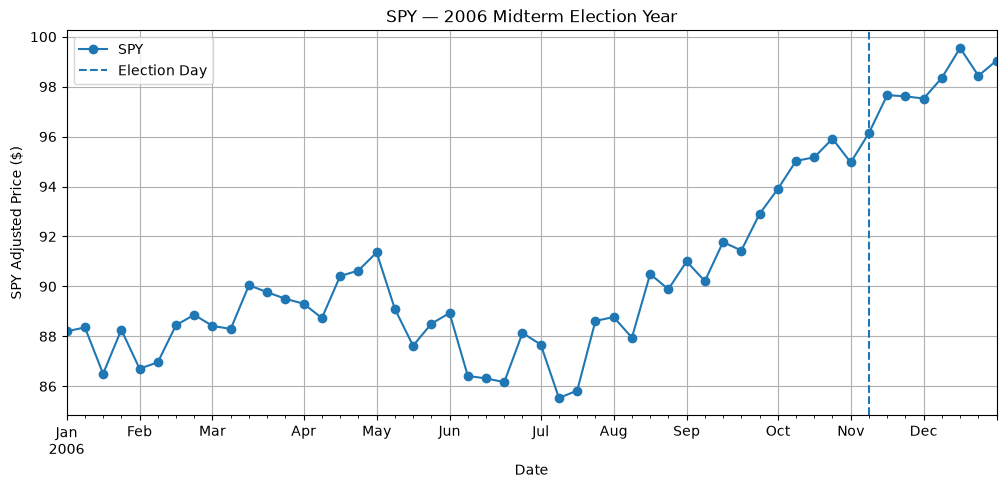

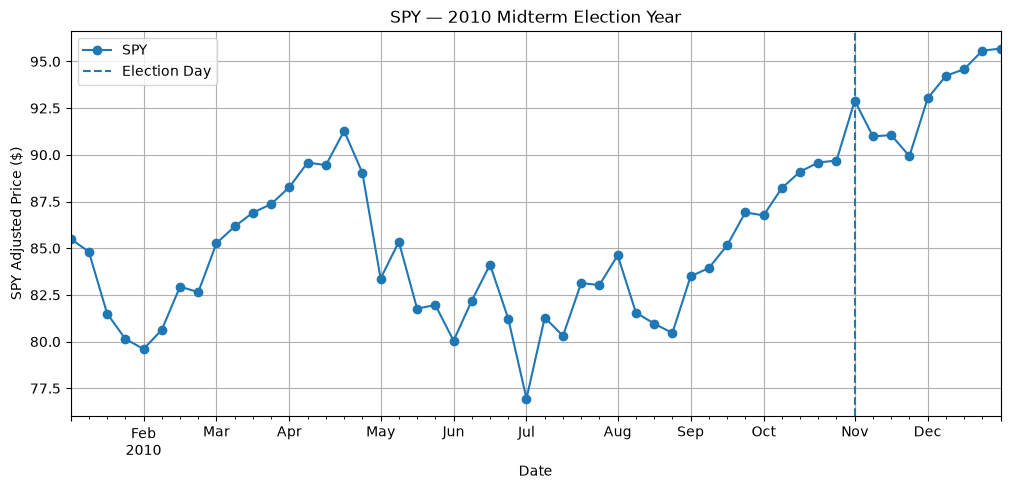

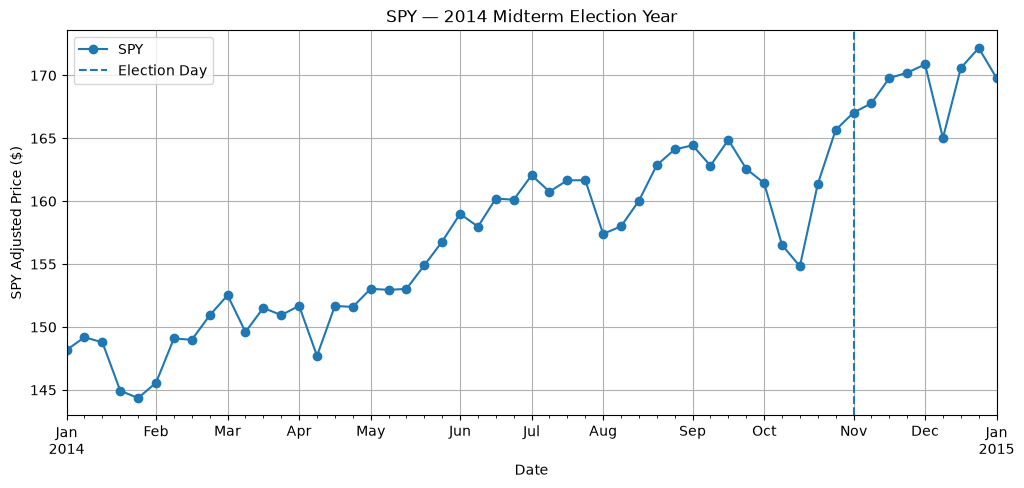

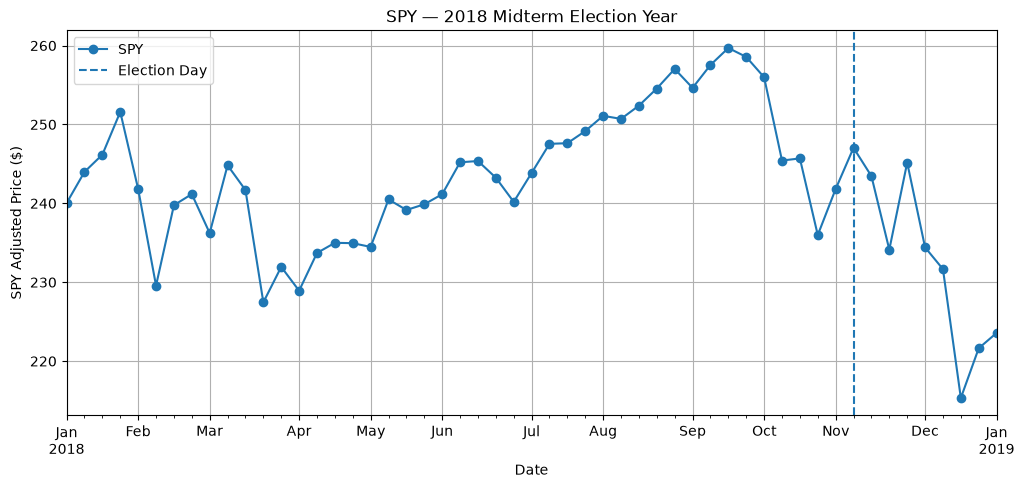

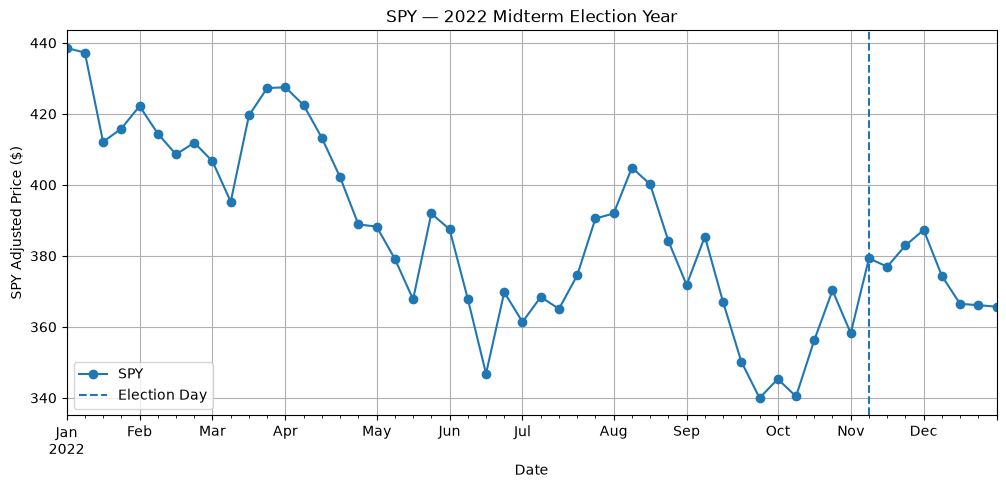

In [4]:
import matplotlib.pyplot as plt
import pandas as pd

midterm_dates = {
    2006: "2006-11-07",
    2010: "2010-11-02",
    2014: "2014-11-04",
    2018: "2018-11-06",
    2022: "2022-11-08"
}

for year, election_date in midterm_dates.items():

    yearly_spy = data["Close"].loc[
        f"{year}-01-01":f"{year}-12-31"
    ]

    weekly_spy = yearly_spy.resample("W-FRI").last()

    weekly_spy.plot(
        figsize=(12, 5),
        marker="o",
        title=f"SPY — {year} Midterm Election Year"
    )

    plt.axvline(
        pd.Timestamp(election_date),
        linestyle="--",
        label="Election Day"
    )

    plt.ylabel("SPY Adjusted Price ($)")
    plt.xlabel("Date")
    plt.grid(True)
    plt.legend()
    plt.show()

[*********************100%***********************]  1 of 1 completed


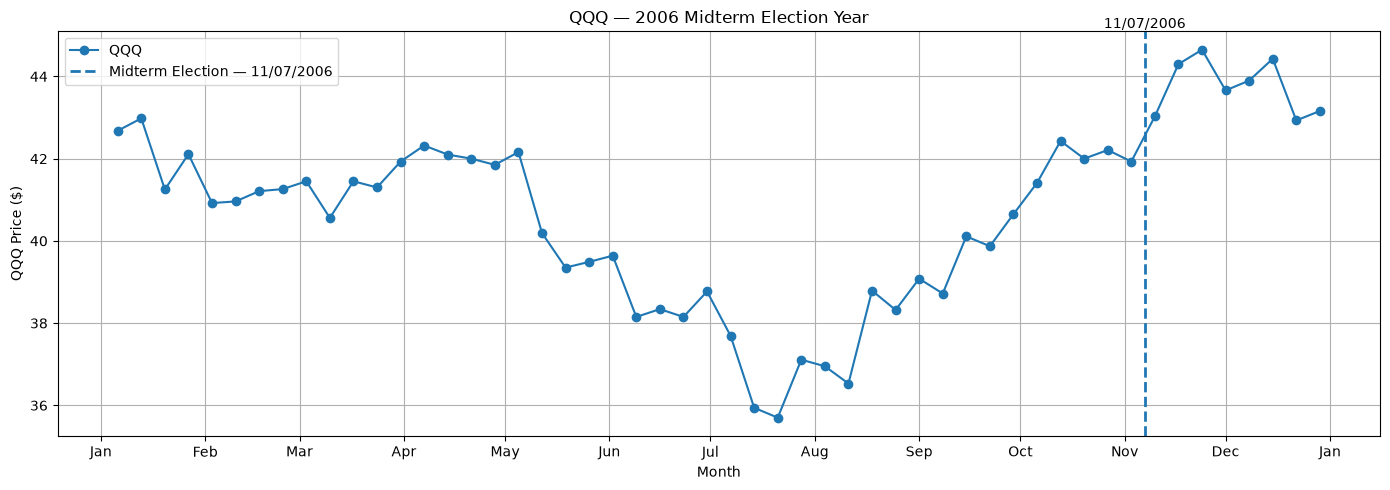

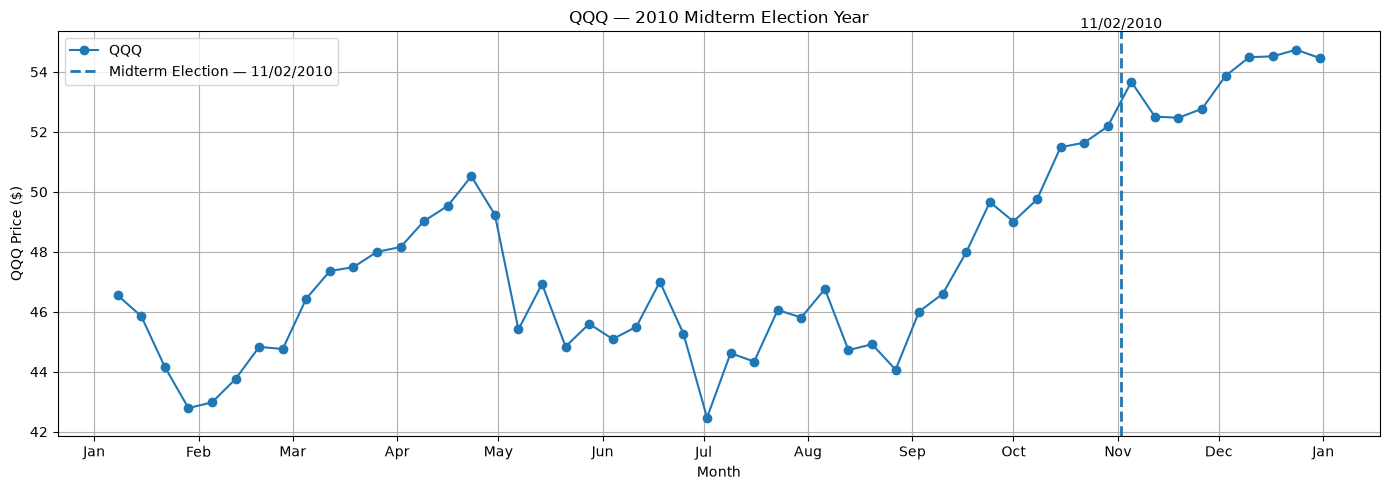

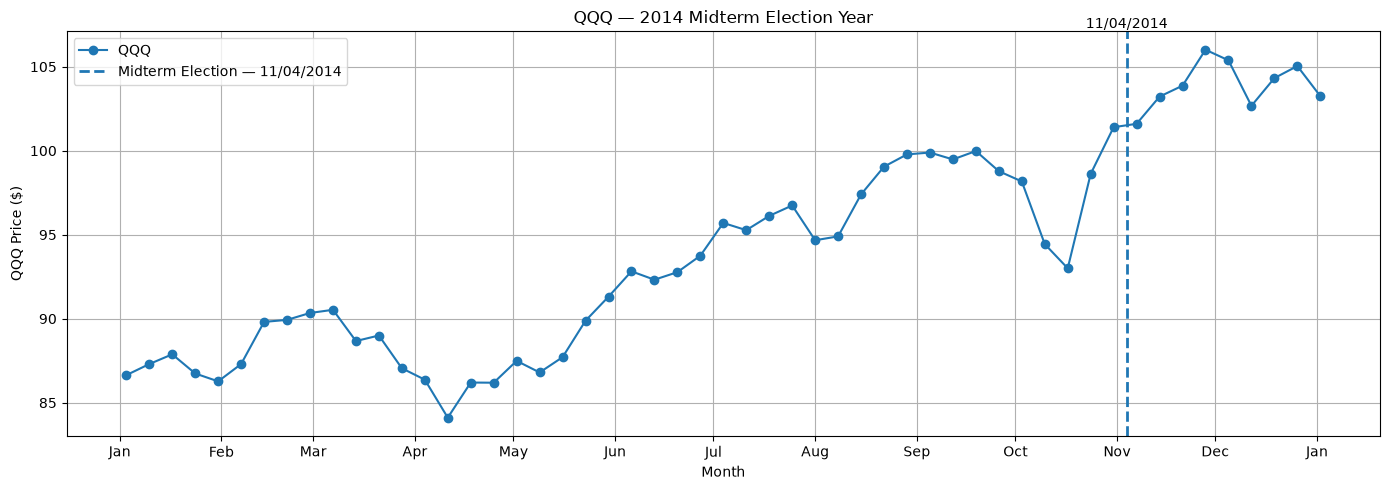

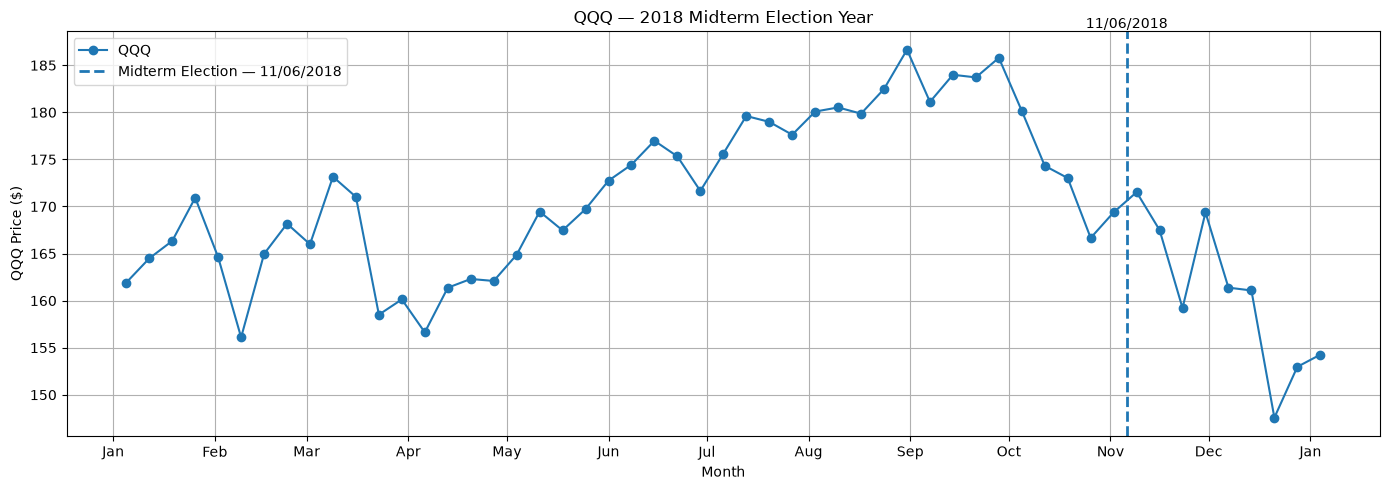

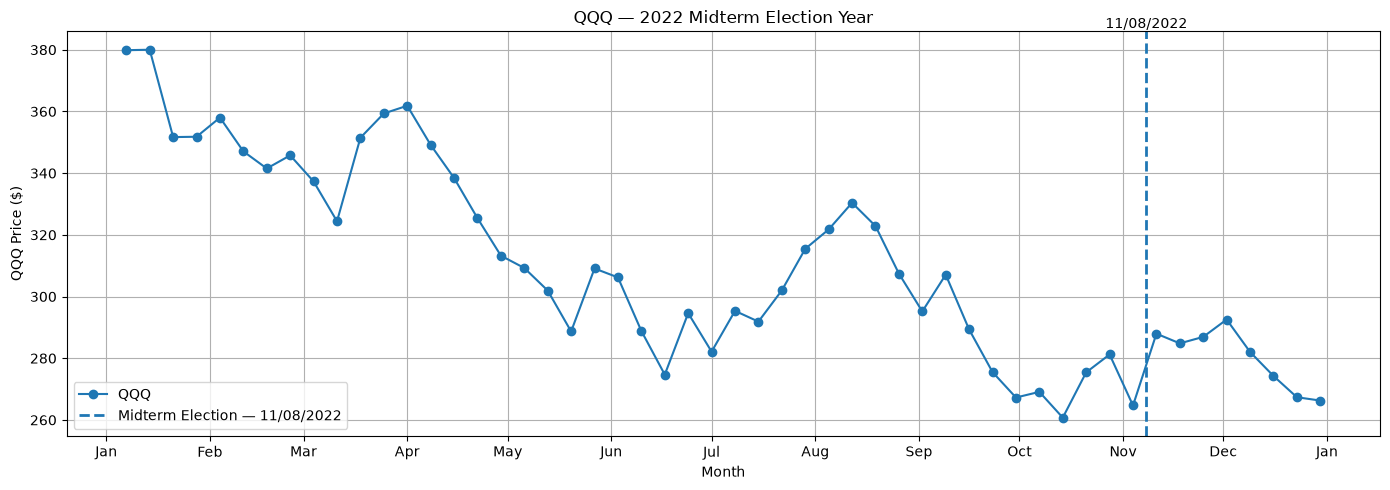

In [11]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Download QQQ actual historical Close prices
qqq = yf.download(
    "QQQ",
    start="2006-01-01",
    end="2023-01-01",
    auto_adjust=False
)

# Midterm election dates
midterm_dates = {
    2006: "2006-11-07",
    2010: "2010-11-02",
    2014: "2014-11-04",
    2018: "2018-11-06",
    2022: "2022-11-08"
}

# Create 5 separate charts
for year, election_date in midterm_dates.items():

    yearly_qqq = qqq["Close"]["QQQ"].loc[
        f"{year}-01-01":f"{year}-12-31"
    ]

    # Weekly data: use last trading day of each week
    weekly_qqq = yearly_qqq.resample("W-FRI").last()

    election = pd.Timestamp(election_date)

    fig, ax = plt.subplots(figsize=(14, 5))

    # QQQ weekly price
    ax.plot(
        weekly_qqq.index,
        weekly_qqq.values,
        marker="o",
        label="QQQ"
    )

    # Midterm election line
    ax.axvline(
        election,
        linestyle="--",
        linewidth=2,
        label=f"Midterm Election — {election.strftime('%m/%d/%Y')}"
    )

    # Exact election date
    ax.text(
        election,
        ax.get_ylim()[1],
        election.strftime("%m/%d/%Y"),
        horizontalalignment="center",
        verticalalignment="bottom"
    )

    # X-axis: month only
    ax.xaxis.set_major_locator(
        mdates.MonthLocator()
    )

    ax.xaxis.set_major_formatter(
        mdates.DateFormatter("%b")
    )

    ax.set_title(
        f"QQQ — {year} Midterm Election Year"
    )

    ax.set_xlabel("Month")
    ax.set_ylabel("QQQ Price ($)")

    ax.grid(True)
    ax.legend()

    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

In [1]:
import pandas as pd

comparison = pd.DataFrame({
    "年份": ["2006", "2010", "2014", "2018", "2022"],

    "SPY": [
        "7月附近见底 → 年底持续上涨",
        "年初跌 → 春季涨 → 夏季回调 → Q4大涨",
        "全年总体上涨，10月回调后创新高",
        "9月见顶 → Q4大跌",
        "全年熊市 → 10月低点 → 选举后反弹"
    ],

    "QQQ": [
        "7月见底 → 年底上涨",
        "几乎完全一样",
        "同样走势",
        "9月见顶 → Q4更猛烈下跌",
        "同方向，但科技股更弱"
    ],

    "主要区别": [
        "非常相似",
        "QQQ振幅更大",
        "QQQ上涨更强",
        "QQQ downside 更大",
        "QQQ受加息冲击更明显"
    ]
})

comparison

,年份,SPY,QQQ,主要区别
0,2006,7月附近见底 → 年底持续上涨,7月见底 → 年底上涨,非常相似
1,2010,年初跌 → 春季涨 → 夏季回调 → Q4大涨,几乎完全一样,QQQ振幅更大
2,2014,全年总体上涨，10月回调后创新高,同样走势,QQQ上涨更强
3,2018,9月见顶 → Q4大跌,9月见顶 → Q4更猛烈下跌,QQQ downside 更大
4,2022,全年熊市 → 10月低点 → 选举后反弹,同方向，但科技股更弱,QQQ受加息冲击更明显


Midterm-year weakness does not appear to occur consistently immediately before Election Day; instead, pullbacks in our sample tend to cluster around July or October.